<a href="https://colab.research.google.com/github/riteshyadav-345/MachineLearning/blob/main/Day15_PolynomialRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Polynomial Regression Example

This notebook demonstrates how to perform Polynomial Regression using `scikit-learn`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

### 1. Generate Sample Data

We'll create some synthetic data with a non-linear relationship to illustrate polynomial regression. The true relationship will be quadratic, with some random noise added.

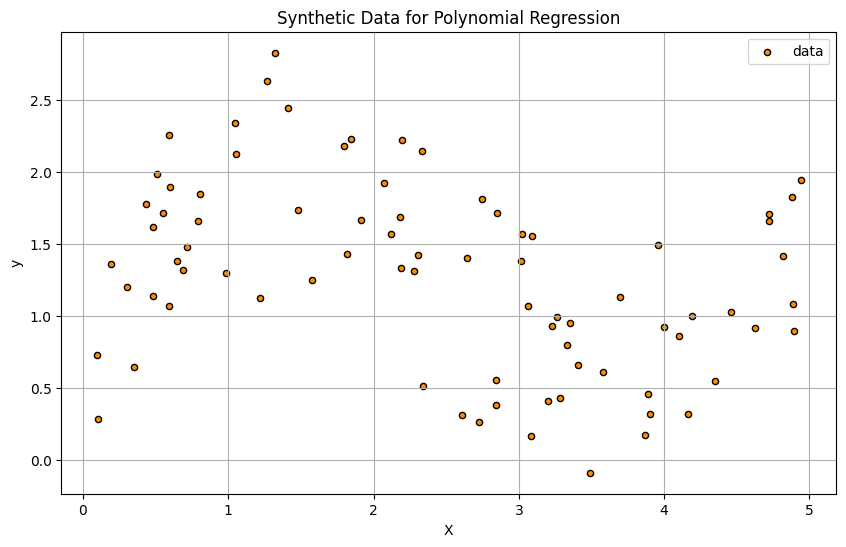

In [2]:
# Generate synthetic data
np.random.seed(0)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.cos(X).ravel() + (X * 0.5).ravel() + np.random.randn(80) * 0.5

plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data for Polynomial Regression")
plt.legend()
plt.grid(True)
plt.show()

### 2. Create Polynomial Features

To fit a polynomial regression model, we first need to transform our input features (`X`) into polynomial features. `PolynomialFeatures` from `scikit-learn` helps us do this.

In [3]:
# Choose the degree of the polynomial
degree = 3
polynomial_features = PolynomialFeatures(degree=degree)
X_poly = polynomial_features.fit_transform(X)

print(f"Original X shape: {X.shape}")
print(f"Transformed X_poly shape (with degree={degree}): {X_poly.shape}")
print("First 5 rows of X_poly:")
print(X_poly[:5])

Original X shape: (80, 1)
Transformed X_poly shape (with degree=3): (80, 4)
First 5 rows of X_poly:
[[1.00000000e+00 9.39490022e-02 8.82641501e-03 8.29232883e-04]
 [1.00000000e+00 1.01091987e-01 1.02195899e-02 1.03311865e-03]
 [1.00000000e+00 1.95938961e-01 3.83920765e-02 7.52250360e-03]
 [1.00000000e+00 3.01127358e-01 9.06776858e-02 2.73055320e-02]
 [1.00000000e+00 3.55180291e-01 1.26153039e-01 4.48070731e-02]]


### 3. Train a Linear Regression Model

After transforming the features, we can train a standard `LinearRegression` model on the polynomial features. This is essentially linear regression, but in a higher-dimensional feature space, which allows it to fit non-linear relationships.

In [4]:
# Create and train the Linear Regression model on the polynomial features
model = LinearRegression()
model.fit(X_poly, y)

# Make predictions
y_pred = model.predict(X_poly)

print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")
print(f"R-squared score: {r2_score(y, y_pred):.4f}")

Model coefficients: [ 0.          2.58191019 -1.33154888  0.17365679]
Model intercept: 0.48988321438305293
R-squared score: 0.4926


### 4. Visualize the Results

Finally, we plot the original data points and the fitted polynomial curve to visually inspect how well the model captured the underlying pattern.

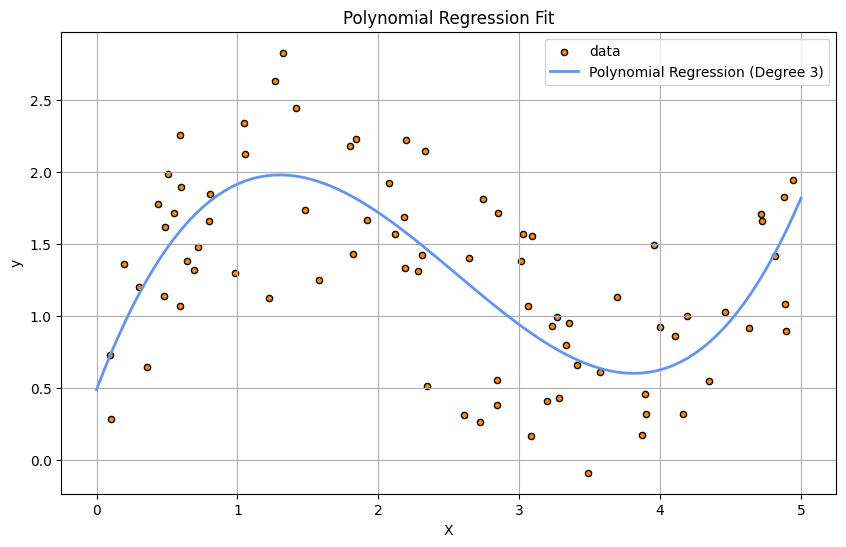

In [5]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")

# Sort the values to ensure a smooth line for the plot
X_plot = np.linspace(0, 5, 100).reshape(-1, 1)
X_plot_poly = polynomial_features.transform(X_plot)
y_plot_pred = model.predict(X_plot_poly)

plt.plot(X_plot, y_plot_pred, color="cornflowerblue", linewidth=2, label=f"Polynomial Regression (Degree {degree})")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression Fit")
plt.legend()
plt.grid(True)
plt.show()